<div align="center" style="
    background: linear-gradient(135deg, #667eea, #764ba2);
    padding:35px;
    border-radius:15px;
    box-shadow:0 8px 25px rgba(0,0,0,0.25);
">
  <h1 style="
      color:white;
      font-family: 'Segoe UI', sans-serif;
      margin:0;
      font-size:42px;
      letter-spacing:1px;
  ">
     Feature Engeinering
  </h1>
</div>

<h3 style="
    text-align:left;
    font-family: 'Georgia', serif;
    font-weight:600;
    letter-spacing:1.5px;
    color:#2c3e50;
">
    🏠 99 Acres by Prince Kumar
</h3>

In [1]:
import pandas as pd 
import numpy as np 

In [2]:
df = pd.read_csv('Gurgaon_House_Flat_Cleaned.csv')

In [3]:
df.shape

(2668, 15)

In [4]:
df.isnull().sum()

Unnamed: 0           0
property_name        0
per_sqft             0
bedroom              0
bathroom             0
configuration        0
area                 0
area_type            0
floor_number         0
facing            1100
age_possession       0
features          1289
location             0
property_type        0
price_cr             0
dtype: int64

In [5]:
df['features'].unique()

array(['Garden', nan, 'Parking, Garden',
       'Parking, Lift, Power Backup, Garden, Security, Play Area, Gated Community',
       'Swimming Pool, Gym', 'Parking', 'Swimming Pool, Garden', 'Gym',
       'Parking, Swimming Pool, Club House, Vastu Compliant',
       'Power Backup', 'Swimming Pool', 'Gym, Club House, Security',
       'Parking, Club House', 'Gym, Play Area', 'Power Backup, Garden',
       'Parking, Power Backup', 'Swimming Pool, Gym, Club House',
       'Piped Gas', 'Parking, Garden, Security', 'Club House',
       'Power Backup, Gated Community', 'Swimming Pool, Gym, Garden',
       'Lift', 'Parking, Gym, Club House', 'Gym, Garden',
       'Swimming Pool, Gym, Club House, CCTV',
       'Swimming Pool, Club House', 'Security', 'Gym, Club House',
       'Power Backup, Security', 'Security, Intercom', 'Lift, Gym',
       'Power Backup, Gym, Tennis Court',
       'Parking, Power Backup, Swimming Pool, Gym, Garden',
       'Swimming Pool, Gym, Garden, Play Area, Badminton Co

In [6]:
from sklearn.preprocessing import MultiLabelBinarizer

# Convert string to list
df['Feature_list'] = df['features'].apply(
    lambda x: [i.strip() for i in x.split(',')] if pd.notnull(x) else []
)

mlb = MultiLabelBinarizer()
feature_binary_matrix = mlb.fit_transform(df['Feature_list'])

feature_binary_df = pd.DataFrame(
    feature_binary_matrix,
    columns=mlb.classes_,
    index=df.index
)



In [7]:
feature_binary_df.shape

(2668, 22)

In [ ]:
# Making clusters on the basis of features porvided 

In [8]:
from sklearn.cluster import KMeans

In [9]:
wcss_reduce = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(feature_binary_df)
    wcss_reduce.append(kmeans.inertia_)

In [10]:
import matplotlib.pyplot as plt

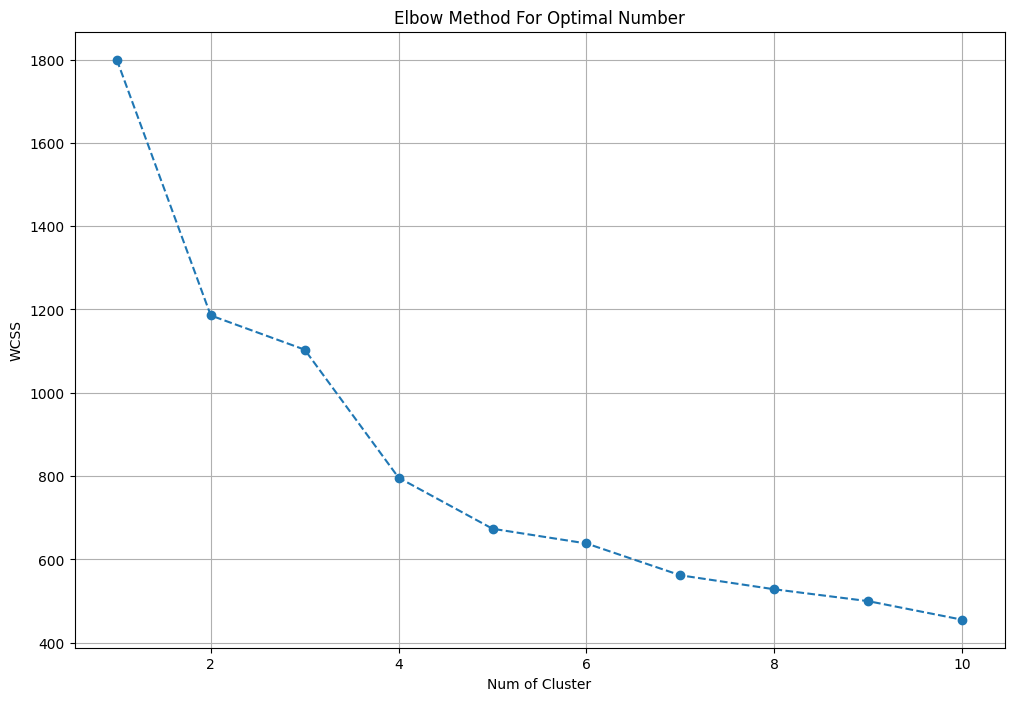

In [11]:
plt.figure(figsize=(12,8))
plt.plot(range(1,11),wcss_reduce,marker='o',linestyle='--')
plt.title('Elbow Method For Optimal Number')
plt.xlabel('Num of Cluster')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [12]:
luxury_weights = {
    "Swimming Pool": 9,
    "Club House": 8,
    "Gym": 8,
    "Tennis Court": 9,
    "Squash Court": 9,
    "Badminton Court": 8,
    "Amphitheatre": 8,
    "Indoor Games": 7,
    "Jogging Track": 7,
    
    "Gated Community": 8,
    "Security": 7,
    "CCTV": 7,
    "Lift": 7,
    "Garden": 6,
    "Park": 6,
    "Play Area": 6,
    "Intercom": 6,
    "Piped Gas": 6,
    
    "Parking": 6,
    "Power Backup": 7,
    "Water Supply": 5,
    "Vastu Compliant": 5
}

In [13]:
luxury_score = feature_binary_df[list(luxury_weights.keys())].multiply(list(luxury_weights.values())).sum(axis=1)

In [14]:
df['Luxury_score'] = luxury_score

In [15]:
df.sample(5)

,Unnamed: 0,property_name,per_sqft,bedroom,bathroom,configuration,area,area_type,floor_number,facing,age_possession,features,location,property_type,price_cr,Feature_list,Luxury_score
379,379,"3 BHK Flat in Sector 102, Gurgaon",13763.0,3,3,3,1889.0,Super Built-up,0.0,NaN,Ready To Move,Swimming Pool,Adani M2K Oyster Grande,Flat,2.60,[Swimming Pool],9
2643,2643,"4 Bedroom House in Tekchand Nagar, Gurgaon",12820.0,4,3,4,780.0,Super Built-up,0.0,NaN,RESALE,NaN,"Tekchand Nagar, Gurgaon",House,1.00,[],0
451,451,"4 BHK Flat in Sector 82A, Gurgaon",16890.0,4,4,4,2309.0,Super Built-up,32.0,West,Ready To Move,Garden,DLF The Primus,Flat,3.90,[Garden],6
74,74,"2 BHK Flat in Sector 107, Gurgaon",11734.0,2,2,2,1534.0,Built-up,12.0,East,Ready To Move,NaN,M3M Woodshire,Flat,1.80,[],0
1500,1500,"3 BHK Flat in Sector 106, Gurgaon",10113.0,3,4,3,1760.0,Super Built-up,0.0,North-East,Ready To Move,NaN,Paras Dews,Flat,1.78,[],0


In [16]:
df['location'].unique()

array(['Hero Homes', 'Piedmont Taksila heights',
       'Unitech The World Spa West', 'Ace Palm Floors', 'ATS Triumph',
       'Unitech Fresco', 'Sare Homes', 'La Vida by Tata Housing',
       'Smartworld The Edition', 'Smartworld sky arc', 'MSL Apartments',
       'M3M Heights', 'Smart World Sky Arc', 'Smartworld Sky Arc',
       'Emaar MGF Palm Hills', 'Assotech Blith',
       'Delphine Central Park Estates', 'ILD Greens', 'Sobha City',
       'SS Linden Floors', 'AWHO Devinder Vihar', 'TARC Ishva',
       'Sare Crescent Parc', 'Signature Global De Luxe DXP',
       'Parsvnath Exotica', 'M3M Altitude', 'Suncity Avenue 102',
       'Godrej aria 101, tower H , suprema', 'Puri Emerald Bay',
       'Vatika Sovereign Park', 'CGHS Prithvi Apartments',
       'Pyramid Fusion Homes', 'Conscient Elevate', 'DLF The Grove',
       'Emaar Mgf Palm Terraces Select', 'DLF New Town Heights 2',
       'Godrej 101', 'Ireo Skyon', 'Godrej Zenith', 'DLF The Ultima',
       'Tata Primanti', 'Bestech Par

In [17]:
df['location'].nunique()

623

In [18]:
society_mean = df.groupby("location")["price_cr"].mean()


In [19]:
df["society_encoded"] = df["location"].map(society_mean)


In [20]:
df.sample(5)

,Unnamed: 0,property_name,per_sqft,bedroom,bathroom,configuration,area,area_type,floor_number,facing,age_possession,features,location,property_type,price_cr,Feature_list,Luxury_score,society_encoded
1079,1079,"3 BHK Flat in Sector 67A, Gurgaon",16502.0,3,3,3,1727.0,Super Built-up,14.0,North-East,Ready To Move,Garden,Ireo The Corridors,Flat,2.85,[Garden],6,2.925333
240,240,"3 BHK Flat in Sector 66, Gurgaon",25806.0,3,3,3,1950.0,Super Built-up,7.0,North,Ready To Move,Garden,Emaar MGF The Palm Drive,Flat,4.00,[Garden],6,4.582414
1077,1077,"3 BHK Flat in Sector 37C, Gurgaon",8266.0,3,3,3,1875.0,Super Built-up,18.0,North-East,Ready To Move,NaN,ILD Greens,Flat,1.55,[],0,1.812500
308,308,"4 BHK Flat in Sector 65, Gurgaon",29447.0,4,4,4,4992.0,Super Built-up,0.0,North,Ready To Move,Garden,M3M Golfestate,Flat,14.70,[Garden],6,12.860500
1952,1952,"10 Bedroom House in DLF Phase 4, Gurgaon",40123.0,10,11,10,3240.0,Super Built-up,0.0,North-East,RESALE,NaN,"DLF Phase 4, Gurgaon",House,13.00,[],0,12.714286


In [21]:
df.drop(columns=['features'],inplace=True)

In [22]:
df.drop(columns=['Feature_list'],inplace=True)

In [23]:
df.isnull().sum()

Unnamed: 0            0
property_name         0
per_sqft              0
bedroom               0
bathroom              0
configuration         0
area                  0
area_type             0
floor_number          0
facing             1100
age_possession        0
location              0
property_type         0
price_cr              0
Luxury_score          0
society_encoded       0
dtype: int64

In [24]:
pd.set_option('display.max_rows',None)

In [25]:
df['property_name']

0                       2 BHK Flat in Sector 104, Gurgaon
1                       4 BHK Flat in Sector 37C, Gurgaon
2                        4 BHK Flat in Sector 30, Gurgaon
3                        3 BHK Flat in Sector 89, Gurgaon
4                       4 BHK Flat in Sector 104, Gurgaon
5                  3 BHK Flat in Nirvana Country, Gurgaon
6                       4 BHK Flat in Sector 37C, Gurgaon
7                        4 BHK Flat in Sector 92, Gurgaon
8                       4 BHK Flat in Sector 113, Gurgaon
9                        4 BHK Flat in Sector 66, Gurgaon
10                       3 BHK Flat in Sector 69, Gurgaon
11            3 BHK Flat in Sector 1 Imt Manesar, Gurgaon
12                       2 BHK Flat in Sector 65, Gurgaon
13                       4 BHK Flat in Sector 69, Gurgaon
14                       3 BHK Flat in Sector 69, Gurgaon
15                       2 BHK Flat in Sector 65, Gurgaon
16                       4 BHK Flat in Sector 77, Gurgaon
17            

In [26]:
df["property_name"] = (
    df["property_name"]
    .str.extract(r"in (.*?),\s*Gurgaon")[0]
    .str.strip()
)

In [28]:
df['property_name'].unique()

array(['Sector 104', 'Sector 37C', 'Sector 30', 'Sector 89',
       'Nirvana Country', 'Sector 92', 'Sector 113', 'Sector 66',
       'Sector 69', 'Sector 1 Imt Manesar', 'Sector 65', 'Sector 77',
       'Sector 99', 'Sector 108', 'Sector 84', 'Sector 56', 'Sector 63A',
       'Sector 37D', 'Sector 53', 'Sector 102', 'Sector 79', 'Sector 52',
       'Sector 70A', 'Sector 59', 'DLF Phase 5', 'Sector 86', 'Sector 60',
       'Sector 81', 'Sector 72', 'Gwal Pahari', 'Sector 88A', 'Sector 71',
       'Sector 109', 'Sector 107', 'Sector 61', 'Sector 36A',
       'Sector 112', 'Sector 106', 'Sector 63', 'Sector 82A', 'Sector 67',
       'sector 58', 'Sector 103', 'Sector 76', 'Sector 85', 'Sector 47',
       'Sector 1A IMT Manesar', 'Sector 62', 'DLF Phase 3', 'Sector 111',
       'Sector 82', 'Sector 50', 'Sector 48', 'Sector 95', 'Sohna',
       'Sector 83', 'Sector 67A', 'Sector 70', 'Sector 33',
       'Sector-33 Sohna', 'Sector 55', 'Sector 49', 'Sector 68',
       'Sector 90', 'Malibu 

In [29]:
df['property_name'].nunique()

237

In [30]:
sector_mean = df.groupby("property_name")["price_cr"].mean()


In [31]:
df["sector_encoded"] = df["property_name"].map(sector_mean)


In [32]:
df.head()

,Unnamed: 0,property_name,per_sqft,bedroom,bathroom,configuration,area,area_type,floor_number,facing,age_possession,location,property_type,price_cr,Luxury_score,society_encoded,sector_encoded
0,0,Sector 104,14740.0,2,2,2,1099.0,Super Built-up,26.0,North-East,Ready To Move,Hero Homes,Flat,1.62,6,2.071224,2.838395
1,1,Sector 37C,9010.0,4,4,4,1848.0,Super Built-up,0.0,West,Ready To Move,Piedmont Taksila heights,Flat,1.67,0,1.842000,1.740714
2,2,Sector 30,30167.0,4,4,4,5138.0,Carpet,0.0,North,Ready To Move,Unitech The World Spa West,Flat,15.50,0,13.566667,9.437500
3,3,Sector 89,9714.0,3,3,3,1750.0,Built-up,0.0,East,Under Construction,Ace Palm Floors,Flat,1.70,12,1.700000,1.780870
4,4,Sector 104,12063.0,4,4,4,3150.0,Super Built-up,0.0,NaN,Ready To Move,ATS Triumph,Flat,3.80,0,3.817222,2.838395


In [33]:
df.corr(numeric_only=True)

,Unnamed: 0,per_sqft,bedroom,bathroom,configuration,area,floor_number,price_cr,Luxury_score,society_encoded,sector_encoded
Unnamed: 0,1.000000,0.273652,0.382054,0.352634,0.382054,0.174868,-0.350527,0.368163,0.272869,0.393880,0.361990
per_sqft,0.273652,1.000000,0.206563,0.201386,0.206563,-0.114333,-0.130819,0.277351,0.131565,0.296818,0.270791
bedroom,0.382054,0.206563,1.000000,0.958575,1.000000,0.147266,-0.172799,0.371302,0.126923,0.323251,0.328929
bathroom,0.352634,0.201386,0.958575,1.000000,0.958575,0.200451,-0.160859,0.420306,0.130483,0.372210,0.372788
configuration,0.382054,0.206563,1.000000,0.958575,1.000000,0.147266,-0.172799,0.371302,0.126923,0.323251,0.328929
area,0.174868,-0.114333,0.147266,0.200451,0.147266,1.000000,-0.089417,0.565400,0.116574,0.477749,0.374676
floor_number,-0.350527,-0.130819,-0.172799,-0.160859,-0.172799,-0.089417,1.000000,-0.182402,-0.196319,-0.199791,-0.184322
price_cr,0.368163,0.277351,0.371302,0.420306,0.371302,0.565400,-0.182402,1.000000,0.222050,0.888161,0.713119
Luxury_score,0.272869,0.131565,0.126923,0.130483,0.126923,0.116574,-0.196319,0.222050,1.000000,0.226316,0.190202
society_encoded,0.393880,0.296818,0.323251,0.372210,0.323251,0.477749,-0.199791,0.888161,0.226316,1.000000,0.794832


In [34]:
df.drop(columns = ['Unnamed: 0'],inplace=True)

In [35]:
df.head()

,property_name,per_sqft,bedroom,bathroom,configuration,area,area_type,floor_number,facing,age_possession,location,property_type,price_cr,Luxury_score,society_encoded,sector_encoded
0,Sector 104,14740.0,2,2,2,1099.0,Super Built-up,26.0,North-East,Ready To Move,Hero Homes,Flat,1.62,6,2.071224,2.838395
1,Sector 37C,9010.0,4,4,4,1848.0,Super Built-up,0.0,West,Ready To Move,Piedmont Taksila heights,Flat,1.67,0,1.842000,1.740714
2,Sector 30,30167.0,4,4,4,5138.0,Carpet,0.0,North,Ready To Move,Unitech The World Spa West,Flat,15.50,0,13.566667,9.437500
3,Sector 89,9714.0,3,3,3,1750.0,Built-up,0.0,East,Under Construction,Ace Palm Floors,Flat,1.70,12,1.700000,1.780870
4,Sector 104,12063.0,4,4,4,3150.0,Super Built-up,0.0,NaN,Ready To Move,ATS Triumph,Flat,3.80,0,3.817222,2.838395


In [36]:
df['property_type'].unique()

array(['Flat', 'House'], dtype=object)

In [37]:
df['age_possession'].unique()

array(['Ready To Move', 'Under Construction', 'RESALE'], dtype=object)

In [38]:
df['area_type'].unique()

array(['Super Built-up', 'Carpet', 'Built-up', 'Covered'], dtype=object)

In [39]:
df['facing'].unique()

array(['North-East', 'West', 'North', 'East', nan, 'South', 'South-East',
       'South-West'], dtype=object)

In [40]:
df["facing"] = df["facing"].fillna("Unknown")

In [41]:
df.isnull().sum()

property_name      0
per_sqft           0
bedroom            0
bathroom           0
configuration      0
area               0
area_type          0
floor_number       0
facing             0
age_possession     0
location           0
property_type      0
price_cr           0
Luxury_score       0
society_encoded    0
sector_encoded     0
dtype: int64

In [42]:
df.shape

(2668, 16)

In [43]:
df['facing'].unique()


array(['North-East', 'West', 'North', 'East', 'Unknown', 'South',
       'South-East', 'South-West'], dtype=object)

In [44]:
df.sample(10)

,property_name,per_sqft,bedroom,bathroom,configuration,area,area_type,floor_number,facing,age_possession,location,property_type,price_cr,Luxury_score,society_encoded,sector_encoded
1267,Sector 89,14328.0,3,4,3,2345.0,Super Built-up,0.0,Unknown,Under Construction,Godrej Zenith,Flat,3.36,0,3.142857,1.780870
2249,Sector 109,349819.0,5,5,5,272.0,Super Built-up,0.0,North-East,RESALE,International City by Sobha Phase 1,House,9.52,6,11.018378,9.683529
768,Sector 48,19470.0,1,1,1,1361.0,Super Built-up,17.0,East,Ready To Move,Central Park The Room,Flat,2.65,6,2.700000,9.550147
2425,Rajendra Park,15909.0,3,3,3,900.0,Super Built-up,0.0,Unknown,RESALE,urban home,House,1.40,6,1.237500,1.207143
1807,"Block C, Sushant Lok Phase 1",40811.0,2,2,2,1506.0,Super Built-up,0.0,Unknown,RESALE,"Block C, Sushant Lok Phase 1, Gurgaon",House,6.15,12,7.604483,8.013333
2216,Sushant Lok Phase 1,15937.0,5,6,5,8000.0,Built-up,0.0,Unknown,RESALE,Independent villa,House,12.75,6,12.750000,12.167600
324,Sector 47,21862.0,3,5,3,2470.0,Super Built-up,20.0,Unknown,Ready To Move,Bestech Park View Spa,Flat,5.40,16,6.374000,6.442500
83,Sector 108,20270.0,3,3,3,2072.0,Super Built-up,0.0,East,Ready To Move,Sobha City,Flat,4.20,6,4.504222,4.329388
816,Sector 62,23205.0,2,2,2,1508.0,Super Built-up,0.0,East,Ready To Move,Emaar Digihomes,Flat,3.50,6,4.346154,7.190000
320,Sector 70A,14992.0,2,2,2,1414.0,Super Built-up,28.0,North-East,Ready To Move,AIPL Zen Residences,Flat,2.12,6,2.512500,3.154516


In [45]:
df.to_csv('Gurgaon_House_Flat_Cleaned_FE.csv')